# CaBER quickstart — Newtonian filament thinning

Video → filament neck radius vs time → thinning analysis, using the bundled
test clip: a **6000 cP viscosity-standard oil** (Newtonian) filament thinning
to breakup, recorded at 100 fps.

> ⚠️ The install cell below is the load-bearing piece for Pyodide/JupyterLite:
> `opencv-python` (not the headless build) is installed the same way as in the
> original `video_input.ipynb`, where it was verified to work in Pyodide.

In [1]:
%pip install -q opencv-python pillow ipywidgets caber

Note: you may need to restart the kernel to use updated packages.


In [2]:
import caber
from caber.data import test_clip_path, TEST_CLIP_FPS, TEST_CLIP_URL
from caber.io import open_video

# The test clip is not shipped in the wheel: downloaded once from
# the public URL below, then cached under ~/.cache/caber/.
print("downloading from:", TEST_CLIP_URL)
clip = test_clip_path()
cap, info = open_video(clip)
print(f"{info.n_frames} frames, {info.width}x{info.height}, container fps={info.fps_container:.1f}")
print(f"true acquisition rate: {TEST_CLIP_FPS:.0f} fps (from the camera overlay timestamps)")
cap.release()

downloading from: https://raw.githubusercontent.com/rheopy/capillary-breakup/main/data/test_clip.mp4
131 frames, 310x226, container fps=100.0
true acquisition rate: 100 fps (from the camera overlay timestamps)


## Interactive ROI definition

Tune the crop/threshold live, then **Run Full Analysis**. The filament here is
*dark on a bright background* and runs *horizontally*, so set those two dropdowns
accordingly.

In [3]:
from caber.widgets import CaberVideo

viewer = CaberVideo(clip, fps=TEST_CLIP_FPS)
viewer.polarity.value = "dark"
viewer.axis.value = "horizontal"
viewer

CaberVideo(children=(IntSlider(value=0, continuous_update=False, description='Frame:', max=130), HBox(children…

## Headless measurement — video → neck vs time

The same pipeline the widget uses, as pure functions (this is what `caber analyze`
runs on the command line):

 frame  time_s  neck_px
     0    0.00       17
     1    0.01       16
     2    0.02       16
breakup at frame 98


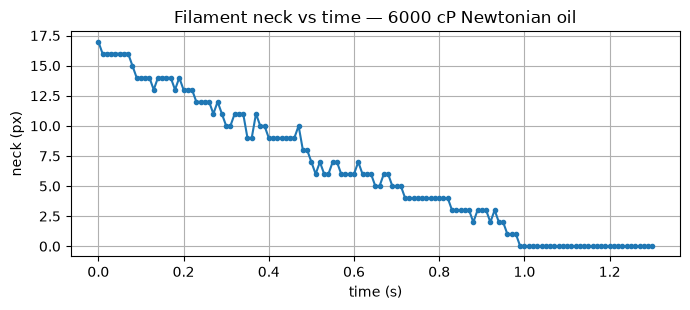

In [4]:
import matplotlib.pyplot as plt

df = caber.measure_video(clip, threshold=100, polarity="dark",
                         axis="horizontal", fps=TEST_CLIP_FPS)
print(df.head(3).to_string(index=False))
print(f"breakup at frame {caber.find_breakup(df)}")

plt.figure(figsize=(7, 3.2))
plt.plot(df.time_s, df.neck_px, marker="o", markersize=3)
plt.xlabel("time (s)"); plt.ylabel("neck (px)"); plt.grid(True)
plt.title("Filament neck vs time — 6000 cP Newtonian oil")
plt.tight_layout(); plt.show()

## Newtonian thinning analysis

Near breakup a Newtonian filament follows the Papageorgiou similarity solution —
radius shrinks **linearly** in time: $R(t) = 0.0709\,(\sigma/\eta)\,(t_c - t)$.
The thinning slope therefore gives the viscosity once the surface tension is known.

Pixel calibration for the demo clip is left as an explicit input (`mm_per_px`):
the source recording's annotation gives 6 mm / 456 px = 0.01316 mm/px in the
wide-view regime; the zoomed regime's scale is not independently established,
so the viscosity below is illustrative of the method.

slope dR/dt = -0.1662 mm/s, R^2 = 0.7579
breakup time t_c = 1.102 s
Newtonian viscosity ≈ 8.96 Pa·s


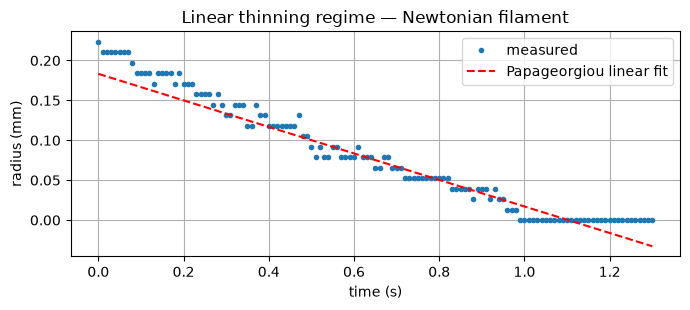

In [5]:
MM_PER_PX = 0.01316 * 2  # wide-view calibration x clip downsample (see note above)

summary = caber.thinning_summary(df, mm_per_px=MM_PER_PX,
                                 surface_tension_mN_per_m=21.0)
rdf, fit = summary["df"], summary["fit"]
print(f"slope dR/dt = {fit['slope']:.4f} mm/s, R^2 = {fit['r_squared']:.4f}")
print(f"breakup time t_c = {fit['t_c']:.3f} s")
print(f"Newtonian viscosity ≈ {summary['viscosity_Pa_s']:.2f} Pa·s")

plt.figure(figsize=(7, 3.2))
plt.plot(rdf.time_s, rdf.radius_mm, "o", markersize=3, label="measured")
t = rdf.time_s
plt.plot(t, fit["intercept"] + fit["slope"]*t, "r--", label="Papageorgiou linear fit")
plt.xlabel("time (s)"); plt.ylabel("radius (mm)"); plt.grid(True); plt.legend()
plt.title("Linear thinning regime — Newtonian filament")
plt.tight_layout(); plt.show()